Regularized cost: 0.6850849138741673
Iteration    0: Cost 0.6930034534766119   
Iteration 100000: Cost 2.41182968579315   
Iteration 200000: Cost 3.39504705080255   
Iteration 300000: Cost 4.053416769657163   
Iteration 400000: Cost 4.557180681006257   
Iteration 500000: Cost 4.9687491206592584   
Iteration 600000: Cost 5.3184873271539095   
Iteration 700000: Cost 5.623617272853958   
Iteration 800000: Cost 5.894910958529143   
Iteration 900000: Cost 6.139582983932942   

updated parameters: w:[6.50946264 5.82695387], b:0.4084533680568467


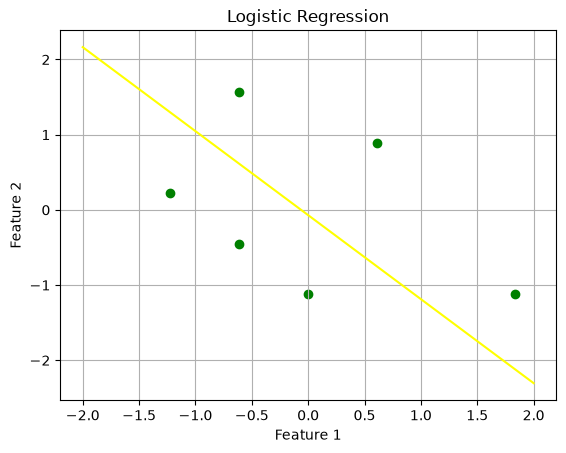

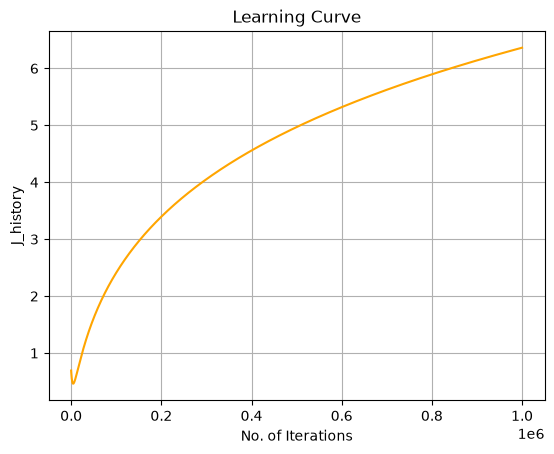

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

x_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

def sigmoid(z):
    return 1/ (1 + np.exp(-z))

def z_score_norm(x):
    mu = np.mean(x, axis = 0)
    s = np.std(x, axis = 0)
    x_norm = (x - mu)/s
    return x_norm, mu, s

x_train = z_score_norm(x_train)[0]

def compute_cost(x, y, w, b, l = 1):
    m, n = x.shape
    cost = 0.0
    for i in range(len(x)):
        fx = sigmoid(np.dot(w,x[i]) + b)
        cost += (y[i] * np.log(fx)) + ((1-y[i]) * np.log(1 - fx))
    cost = cost / (-len(x))

    reg_cost = 0.0
    for j in range(n):
        reg_cost += w[j] ** 2
    reg_cost = (l * reg_cost) / (2*m)

    total_cost = cost + reg_cost
    return total_cost

np.random.seed(1)
X_tmp = np.random.rand(5,6)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).reshape(-1,)-0.5
b_tmp = 0.5
lambda_tmp = 0.7
cost_tmp = compute_cost(X_tmp, y_tmp, w_tmp, b_tmp, lambda_tmp)

print("Regularized cost:", cost_tmp)

def compute_gradient(x, y, w, b):
    m, n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0
    for i in range(m):
        z = np.dot(w, x[i]) + b
        err = sigmoid(z) - y[i]
        for j in range(n):
            dj_dw[j] += err * x[i,j]
        dj_db += err


    for j in range(n):


    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

def gradient_descent(x, y, wi, bi, alpha, iters, cost_fn, gradient_fn):
    w = wi
    b = bi
    J = [cost_fn(x, y, w, b)]
    num_iters = [0]

    for i in range(iters):
        dj_dw, dj_db = gradient_fn(x, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J.append(cost_fn(x, y, w, b))
        num_iters.append(i)

        if i % math.ceil(iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J[-1]}   ")

    return w, b, J, num_iters

w_tmp = np.zeros_like(x_train[0])
b_tmp = 0.
alph = 0.001
iters = 1000000

w_out, b_out, _, n = gradient_descent(x_train, y_train, w_tmp, b_tmp, alph, iters, compute_cost, compute_gradient)
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

plt.scatter(x_train[:,0], x_train[:,1], color = "green")
x1 = np.linspace(-2,2,50)
x2 = (-b_out - w_out[0] * x1)/w_out[1]
plt.plot(x1, x2, color = "yellow")
plt.title("Logistic Regression")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.show()

#plot the learning curve
plt.plot(n, _, color = "orange")
plt.title("Learning Curve")
plt.xlabel("No. of Iterations")
plt.ylabel("J_history")
plt.grid()
plt.show()
